# Metrics Driven Development: Latency Analysis

Сравнить существующую и улучшенную версии системы по метрике latency и принять архитектурное решение на основе статистического анализа.

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

## Data Generation

В рамках задания рассматриваются две выборки времени отклика системы:

- Existing system: среднее время отклика около 3.5 секунд
- Improved system: среднее время отклика около 2.0 секунд

Размер каждой выборки составляет 500 000 наблюдений.

In [13]:
np.random.seed(42)

existing = np.random.normal(
    loc=3.5,
    scale=0.4,
    size=500000
)

improved = np.random.normal(
    loc=2.0,
    scale=0.4,
    size=500000
)

Рассчитаем основные статистики для обеих систем

In [14]:
print("Existing system")
print(f"Mean: {existing.mean():.4f}")
print(f"Std:  {existing.std():.4f}")

print()

print("Improved system")
print(f"Mean: {improved.mean():.4f}")
print(f"Std:  {improved.std():.4f}")

Existing system
Mean: 3.4995
Std:  0.4002

Improved system
Mean: 1.9992
Std:  0.4000


## Distribution Visualization

Визуализируем распределения времени отклика для двух систем.

Если улучшение действительно существует, распределение новой системы должно быть смещено влево относительно существующей системы.

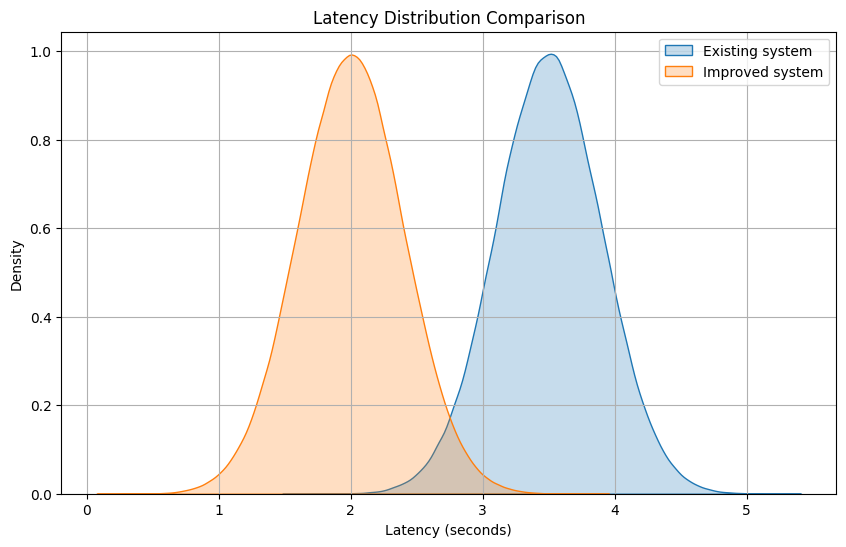

In [15]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    existing,
    label="Existing system",
    fill=True
)

sns.kdeplot(
    improved,
    label="Improved system",
    fill=True
)

plt.title("Latency Distribution Comparison")
plt.xlabel("Latency (seconds)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

## Формулируем гипотезу

Проверяем гипотезу о наличии статистически значимого улучшения.

Нулевая гипотеза:

H₀: среднее время отклика одинаково для обеих систем.

Альтернативная гипотеза:

H₁: улучшенная система имеет меньшее среднее время отклика.

Уровень значимости:

α = 0.05

## Выбор теста

Используется Welch's t-test.

Причины выбора:

- выборки независимы;
- размер выборок очень большой;
- допускается различие дисперсий;
- тест предназначен для сравнения средних значений двух выборок.

In [16]:
t_stat, p_value = stats.ttest_ind(
    existing,
    improved,
    equal_var=False
)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")

alpha = 0.05

if p_value < alpha:
    print("Отвргаем H0")
else:
    print("Не отвергаем H0")

t-statistic: 1875.0792837291906
p-value: 0.0
Отвргаем H0


## Results Interpretation

Полученное значение p-value значительно меньше уровня значимости 0.05.

Следовательно, нулевая гипотеза отвергается.

Разница между двумя версиями системы является статистически значимой и не может быть объяснена случайными колебаниями данных.